In [1]:
# MCMC generate a set of random number from a complex distribution
import numpy as np

def p1(x):
    return np.abs(np.sin(x))*np.exp(-x)

def p2(x):
    return np.sin(x)**2*np.exp(-x)*np.cos(x)**2

def p3(x):
    return np.exp(-x**2)*np.exp(x)

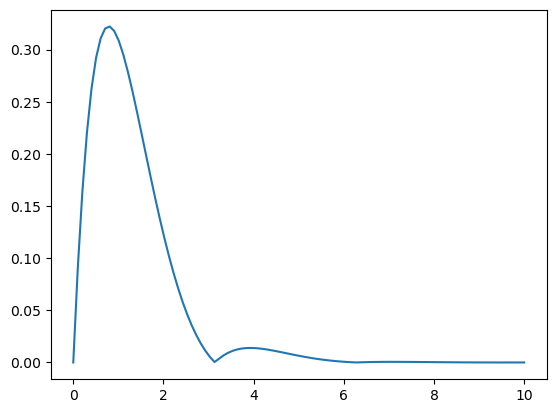

In [ ]:
x = np.linspace(0,10,100)
y = p1(x)

from matplotlib import pyplot as plt
plt.plot(x,y)
plt.show()

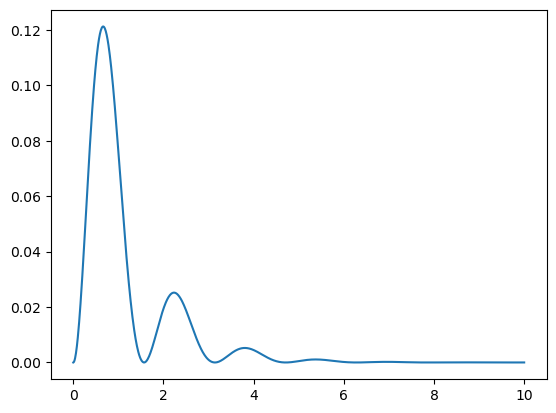

In [43]:
x = np.linspace(0,10,1000)
y = p2(x)

from matplotlib import pyplot as plt
plt.plot(x,y)
plt.show()

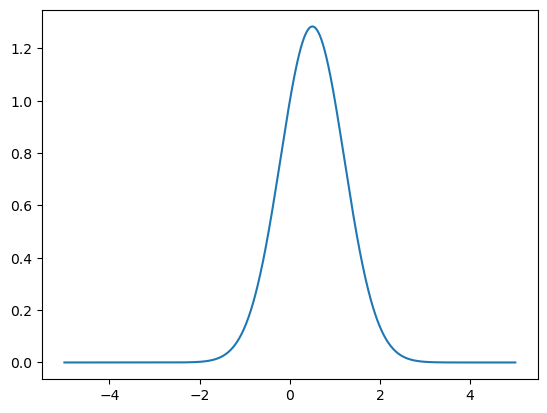

In [59]:
x = np.linspace(-5, 5, 1000)
y = p3(x)

from matplotlib import pyplot as plt
plt.plot(x,y)
plt.show()

In [8]:
from numpy import random 

In [2]:
def get_sample_mc(x_init, x_range, nsample, p_func, step_resol, corr_length=5):
    '''
    x_init: initial x value
    x_range: tuple (min, max) for the sample values
    nsample: number of samples to return
    p_func: the probability distribution function (unnormalized)
    corr_length: thinning factor; keep every N-th step
    '''
    samples = []
    x_current = x_init
    
    # We need to run the loop long enough to account for the correlation length
    total_steps = nsample * corr_length
    
    # Define a proposal width (step size). 
    # Usually ~10% of the range is a good starting point for exploration.
    step_size = (x_range[1] - x_range[0]) * step_resol
    
    for i in range(total_steps):
        # 1. PROPOSAL STEP: 
        # Suggest a new x' by adding some random noise to the current x
        x_proposal = x_current + np.random.normal(0, step_size)
        
        # 2. BOUNDARY CHECK: 
        # If the proposal is out of bounds, we treat p_func(x) as 0 (reject it)
        if x_range[0] <= x_proposal <= x_range[1]:
            
            # 3. ACCEPTANCE CALCULATION:
            # Calculate the ratio of the new probability to the old one
            # Note: We don't need the normalization constant!
            p_proposal = p_func(x_proposal)
            p_current = p_func(x_current)
            
            # Acceptance probability alpha
            alpha = min(1, p_proposal / p_current)
            
            # 4. DECISION:
            # Generate a random number between 0 and 1
            if np.random.rand() < alpha:
                x_current = x_proposal
        
        # 5. THINNING:
        # Only save the sample if we've reached the correlation length
        if (i + 1) % corr_length == 0:
            samples.append(x_current)
            
    return np.array(samples)

In [5]:
x0 = 2
x_range = [-5, 5]
nsample = 1000
mysample1 = get_sample_mc(x0,x_range,nsample, p1, step_resol=0.1, corr_length=5)
mysample2 = get_sample_mc(x0,x_range,nsample, p2, step_resol=0.1, corr_length=5)
mysample3 = get_sample_mc(x0,x_range,nsample, p3, step_resol=0.1, corr_length=5)

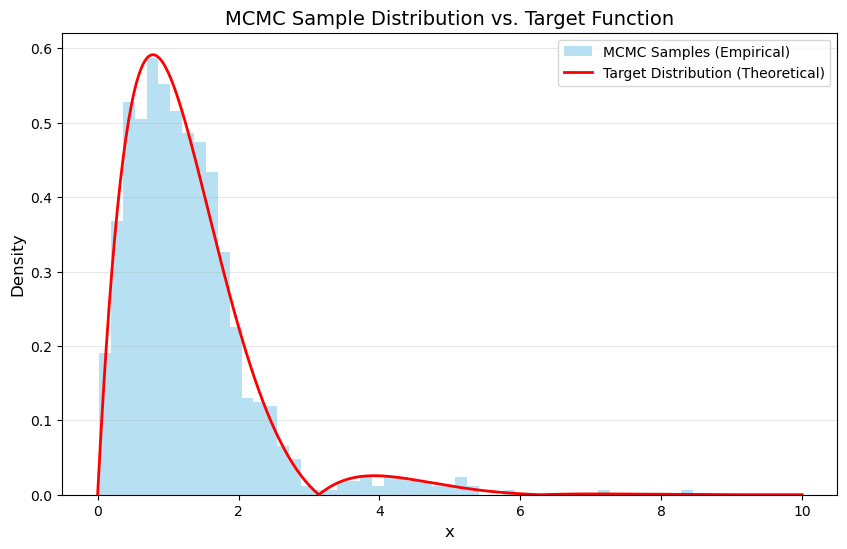

In [53]:
x_range = [0, 10]
x_plot = np.linspace(x_range[0], x_range[1], 500)
y_plot = np.array([p1(x) for x in x_plot])

# 2. Normalize the theoretical curve (optional but recommended)
# This ensures the area under the curve = 1, just like the histogram
from scipy.integrate import quad
area, _ = quad(p1, x_range[0], x_range[1])
y_plot_normalized = y_plot / area

# 3. Create the plot
plt.figure(figsize=(10, 6))

# Plot the histogram of samples
# 'density=True' is key: it scales the histogram so the total area is 1
plt.hist(mysample1, bins=50, density=True, alpha=0.6, color='skyblue', 
        label='MCMC Samples (Empirical)')

# Plot the original function (normalized)
plt.plot(x_plot, y_plot_normalized, color='red', lw=2, 
            label='Target Distribution (Theoretical)')

# 4. Formatting
plt.title('MCMC Sample Distribution vs. Target Function', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

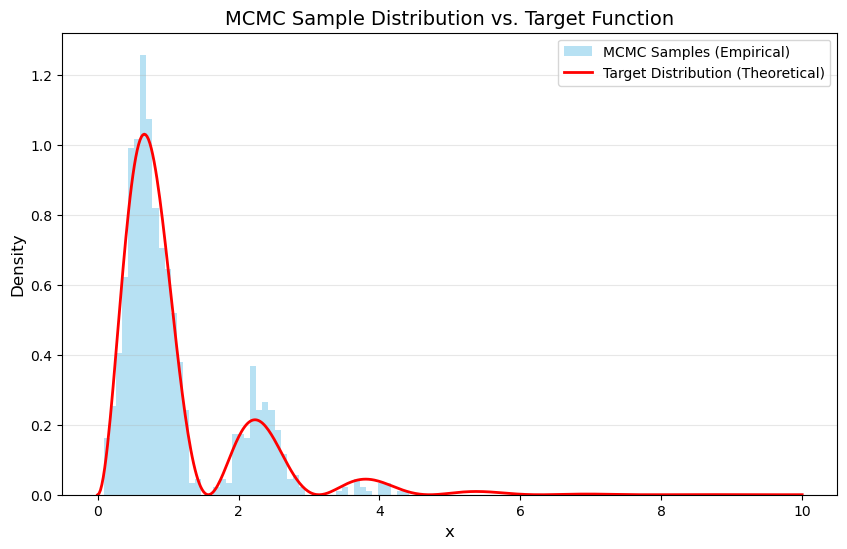

In [54]:
# x_range = [0, 10]
x_plot = np.linspace(x_range[0], x_range[1], 500)
y_plot = np.array([p2(x) for x in x_plot])

# 2. Normalize the theoretical curve (optional but recommended)
# This ensures the area under the curve = 1, just like the histogram
from scipy.integrate import quad
area, _ = quad(p2, x_range[0], x_range[1])
y_plot_normalized = y_plot / area

# 3. Create the plot
plt.figure(figsize=(10, 6))

# Plot the histogram of samples
# 'density=True' is key: it scales the histogram so the total area is 1
plt.hist(mysample2, bins=50, density=True, alpha=0.6, color='skyblue', 
        label='MCMC Samples (Empirical)')

# Plot the original function (normalized)
plt.plot(x_plot, y_plot_normalized, color='red', lw=2, 
            label='Target Distribution (Theoretical)')

# 4. Formatting
plt.title('MCMC Sample Distribution vs. Target Function', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)

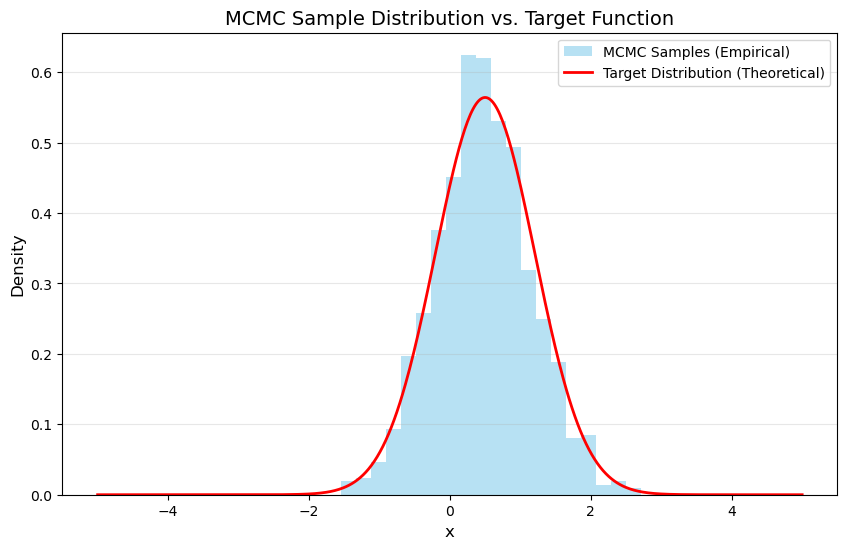

In [8]:
x_plot = np.linspace(x_range[0], x_range[1], 500)
y_plot = np.array([p3(x) for x in x_plot])

# 2. Normalize the theoretical curve (optional but recommended)
# This ensures the area under the curve = 1, just like the histogram
from scipy.integrate import quad
area, _ = quad(p3, x_range[0], x_range[1])
y_plot_normalized = y_plot / area

from matplotlib import pyplot as plt
# 3. Create the plot
plt.figure(figsize=(10, 6))

# Plot the histogram of samples
# 'density=True' is key: it scales the histogram so the total area is 1
plt.hist(mysample3, bins=20, density=True, alpha=0.6, color='skyblue', 
        label='MCMC Samples (Empirical)')

# Plot the original function (normalized)
plt.plot(x_plot, y_plot_normalized, color='red', lw=2, 
            label='Target Distribution (Theoretical)')

# 4. Formatting
plt.title('MCMC Sample Distribution vs. Target Function', fontsize=14)
plt.xlabel('x', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)